In [1]:
import glob
from tqdm import tqdm
import numpy as np
import pickle
year = 2023
H5_FILE = f'/home/magdalena/pipeline/data_preprocessing/data/H5_FILES/{year}/h5_dataset/clean_{year}.h5'
MD_PATH = f'/home/magdalena/pipeline/data_preprocessing/data/H5_FILES/{year}/metadata/metadata_qt_0.joblib'
FT_PATH = ''
dirs = glob.glob(f'/home/magdalena/pipeline/data_preprocessing/sixplusdets/{year}_out/*')

In [2]:
with (open(dirs[0], "rb")) as openfile:
        load = pickle.load(openfile)

IndexError: list index out of range

In [32]:
load['md_cols']

,name,value,fid,sid,version,name_fid,prod
0,W1-W2,nan,,ZTF,1.0.0,W1-W2,W1_W2
1,W2-W3,nan,,ZTF,1.0.0,W2-W3,W2_W3
2,W3-W4,nan,,ZTF,1.0.0,W3-W4,W3_W4
0,sgscore1,NaN,,panstarrs,1.0.1,sgscore1,sgscore1
1,distpsnr1,NaN,,panstarrs,1.0.1,distpsnr1,dist_nr
2,ps_g-r,NaN,,panstarrs,1.0.1,ps_g-r,ps_g_r


In [33]:

r_band_zero_counter = 0
g_band_zero_counter = 0
ft_nans = []
md_nans = []
len_g = []
len_r = []

for dir in tqdm(dirs, total = len(dirs)):
    with (open(dir, "rb")) as openfile:
        load = pickle.load(openfile)
        if load['flux'].sum(axis =0 )[0] == 0:
            g_band_zero_counter +=1
        else:
            len_g.append((load['flux']!=0).sum(axis =0 )[0])
        if load['flux'].sum(axis =0 )[1] == 0:
            r_band_zero_counter +=1
        else:
            len_r.append((load['flux']!=0).sum(axis =0 )[1])
        ft_nans.append(load['ft_cols'].isna().sum())
        md_nans.append(load['md_cols'].isna().sum())

100%|██████████| 19514/19514 [00:18<00:00, 1031.09it/s]


In [34]:

print(f'For a total of {len(dirs)} object, {g_band_zero_counter} have zero observations in the g band, and {r_band_zero_counter} have zero observations in the r band')
print(f'For a total of {len(dirs)} object, the mean nan per objects for the features is {np.mean(ft_nans)} and the mean nan per object for the metadata is {np.mean(md_nans)}')

print(f'{np.mean(len_g)} +/- {np.std(len_g)}')
print(f'{np.mean(len_r)}+/- {np.std(len_r)}')

For a total of 19514 object, 3730 have zero observations in the g band, and 1076 have zero observations in the r band
For a total of 19514 object, the mean nan per objects for the features is 0.0 and the mean nan per object for the metadata is 0.42857142857142855
10.231626964014191 +/- 12.17081285259438
12.952977546371624+/- 19.241834519023513


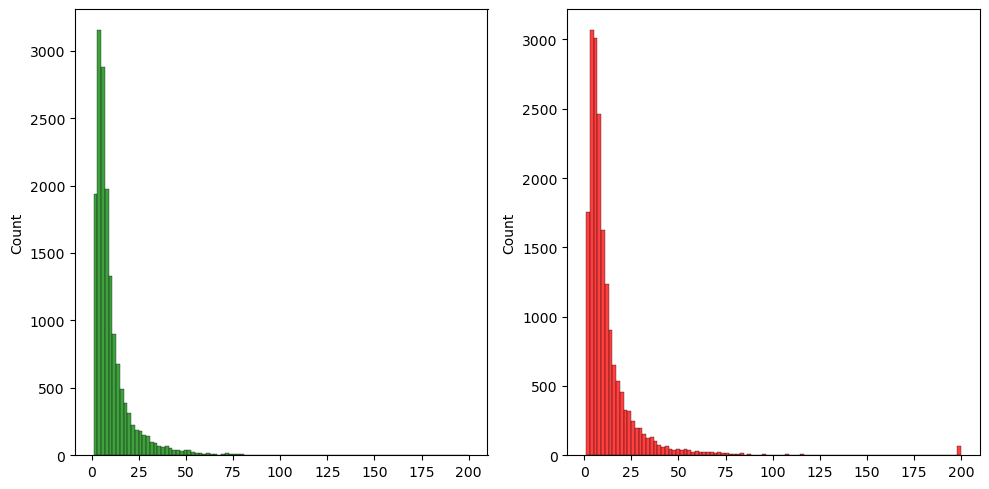

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,2,figsize = (10,5))
sns.histplot(len_g,ax = ax[0],color = 'green',bins = 100)
sns.histplot(len_r,ax = ax[1],color = 'red', bins = 100)
plt.tight_layout()

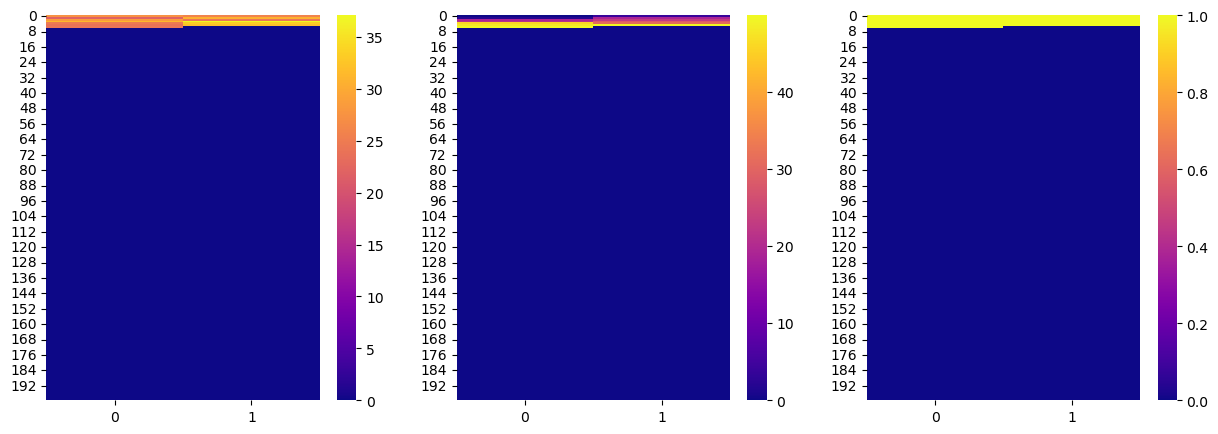

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,3,figsize = (15,5))
sns.heatmap(load['flux'],ax = ax[0], cmap='plasma')
sns.heatmap(load['time'],ax = ax[1], cmap='plasma')
sns.heatmap(load['mask'],ax = ax[2], cmap='plasma')

In [37]:
import h5py
with h5py.File(H5_FILE, 'r') as f:
    # Print original dictionary keys
    
    # Print HDF5 root level keys
    print("HDF5 root level keys:", list(f.keys()))
    these_idx = f.get('validation_0')[:100]
    #print(these_idx)
    feats = f.get('md_cols')[these_idx]

    

HDF5 root level keys: ['flux', 'ft_cols', 'mask', 'md_cols', 'time', 'train_0', 'train_1', 'train_2', 'train_3', 'train_4', 'validation_0', 'validation_1', 'validation_2', 'validation_3', 'validation_4']


In [38]:
feats

array([[[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan]],

       [[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan]],

       [[-0.214],
        [ 1.791],
        [ 2.457],
        [   nan],
        [   nan],
        [   nan]],

       [[-0.013],
        [-0.108],
        [ 3.657],
        [   nan],
        [   nan],
        [   nan]],

       [[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan]],

       [[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan]],

       [[ 1.24 ],
        [ 2.735],
        [ 3.476],
        [   nan],
        [   nan],
        [   nan]],

       [[ 0.545],
        [ 2.286],
        [ 2.69 ],
        [   nan],
        [   nan],
        [   nan]],

       [[-0.022],
        [ 1.77 ],
        [ 3.533],
        [   nan],
        [   nan],
        [   nan]],

       [[ 

In [39]:
import pandas as pd
from joblib import load
QT = load(MD_PATH)
df = pd.DataFrame(feats.reshape(feats.shape[0],feats.shape[1]))
df = QT.transform(df.fillna(12345)) + 0.1
df = pd.DataFrame(df.reshape(df.shape[0],df.shape[1]) )
df = df.fillna(0)
df = df.values.reshape(df.shape[0],df.shape[1],1) 


In [40]:
df

array([[[1.1       ],
        [1.1       ],
        [1.1       ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[1.1       ],
        [1.1       ],
        [1.1       ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.18081349],
        [0.44084084],
        [0.33123123],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.48338338],
        [0.12061739],
        [0.94409409],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[1.1       ],
        [1.1       ],
        [1.1       ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[1.1       ],
        [1.1       ],
        [1.1       ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.9978979 ],
        [0.66222882],
        [0.81404738],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.76866867],
        [0.53487932],
        [0.4161064